<a href="https://colab.research.google.com/github/Shama-Ashraf/CVBasic/blob/main/Copy_of_EVENT4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!unzip CIFAR10-small.zip

Streaming output truncated to the last 5000 lines.
  inflating: testing/image_0001.png  
  inflating: testing/image_0002.png  
  inflating: testing/image_0003.png  
  inflating: testing/image_0004.png  
  inflating: testing/image_0005.png  
  inflating: testing/image_0006.png  
  inflating: testing/image_0007.png  
  inflating: testing/image_0008.png  
  inflating: testing/image_0009.png  
  inflating: testing/image_0010.png  
  inflating: testing/image_0011.png  
  inflating: testing/image_0012.png  
  inflating: testing/image_0013.png  
  inflating: testing/image_0014.png  
  inflating: testing/image_0015.png  
  inflating: testing/image_0016.png  
  inflating: testing/image_0017.png  
  inflating: testing/image_0018.png  
  inflating: testing/image_0019.png  
  inflating: testing/image_0020.png  
  inflating: testing/image_0021.png  
  inflating: testing/image_0022.png  
  inflating: testing/image_0023.png  
  inflating: testing/image_0024.png  
  inflating: testing/image_0025.png  

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
from keras.models import Model
from keras.utils import to_categorical
from keras import regularizers
from PIL import Image

def create_model(input_shape, dense_size, classes):
    kernel_sz = (3, 3)
    x = Input(shape=(input_shape))

    y = Conv2D(filters=32, kernel_size=kernel_sz, strides=1, activation ='relu', padding='same', kernel_initializer='he_normal')(x)
    y = MaxPooling2D()(y)
    y = Conv2D(filters=64, kernel_size=kernel_sz, strides=1, activation ='relu', padding='same', kernel_initializer='he_normal')(y)
    y = MaxPooling2D()(y)
    y = Flatten()(y)
    y = Dense(dense_size, activation='relu')(y)
    y = Dense(classes, activation='softmax', name='dense_layer', kernel_regularizer=regularizers.L2(0.03))(y)
    model = Model(inputs=x, outputs=y)
    return model

def load_labels(filename):
    with open(filename,'r') as file:
       li = file.readlines()
    label_count = len(li)
    labels = np.empty((label_count,1), dtype='int')
    i = 0
    with open(filename) as f:
        for line in f:
            labels[i] = int(line.replace("\n", ""))
            i = i + 1
    return labels

def load_images(folder, image_count, image_size):
    array_shape = (image_count, image_size[0], image_size[1], image_size[2])
    imageset = np.empty(array_shape, dtype='float')
    for i in range(0,image_count):
        image = Image.open(folder + '/image_' + "{:04d}".format(i) + '.png')
        imageset[i] = np.asarray(image)
    return imageset

def normalize_dataset(sampled_images):
	sampled_images = (sampled_images.astype('float32')-128) / 128
	return sampled_images

def split_test_val(data, splitpoint):
    return data[splitpoint:], data[:splitpoint]

########################################################################
Y_test = load_labels('testing/labels.csv')
X_test = load_images('testing', len(Y_test), (32,32,3))

y_train = load_labels('training/labels.csv')
x_train = load_images('training', len(y_train), (32,32,3))

x_train = normalize_dataset(x_train)

##### Test set preparation #####
splitpoint = 2000
X_test = normalize_dataset(X_test)
x_test, x_val = split_test_val(X_test, splitpoint)
y_test, y_val = split_test_val(Y_test, splitpoint)
print('Validation set size', x_val.shape)
print('Test set size:', x_test.shape)
print('')

class_count = len(np.unique(y_train))

# define a neural network for training
dims = (32, 32, 3)
dense_sz = 100
model = create_model(dims, dense_sz, class_count)

model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4), metrics=['accuracy'])
model.fit(x_train, y_train, epochs=12, validation_data=(x_val, y_val))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Validation set size (2000, 32, 32, 3)
Test set size: (3000, 32, 32, 3)

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.2953 - loss: 2.4295 - val_accuracy: 0.4575 - val_loss: 1.8103
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.5016 - loss: 1.6512 - val_accuracy: 0.5110 - val_loss: 1.5575
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.5755 - loss: 1.3929 - val_accuracy: 0.5375 - val_loss: 1.4308
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6153 - loss: 1.2473 - val_accuracy: 0.5560 - val_loss: 1.3639
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6534 - loss: 1.1225 - val_accuracy: 0.5710 - val_loss: 1.3434
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.6770 - loss: 1.0751 - val_accuracy: 0.5710 - val_loss: 1.3143
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7080 - loss: 0.9907 - val_accuracy: 0.5755 - val_loss: 1.2800
Epoch 8/12
313/313

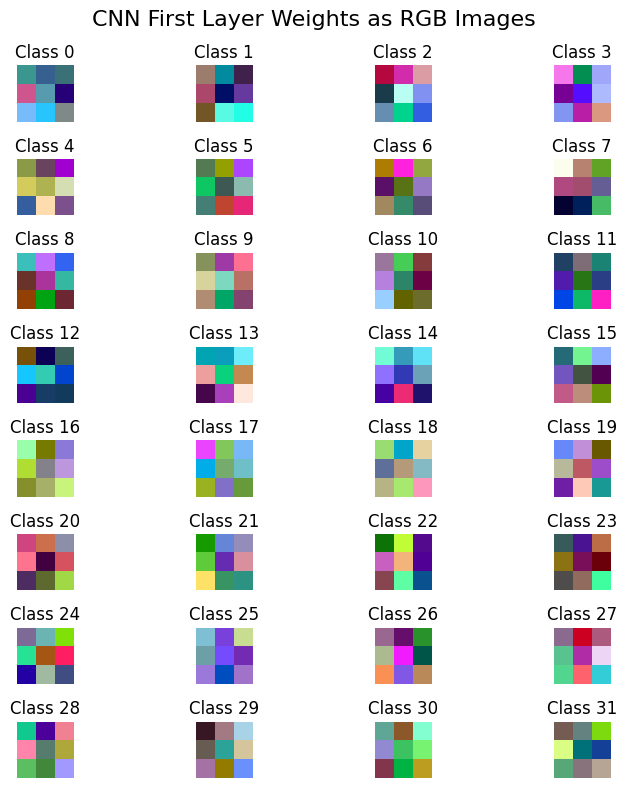

In [11]:
from matplotlib import pyplot as plt
weights, biases = model.get_layer('conv2d_6').get_weights()
height, width, channels = 3, 3, 3
input_shape = (height, width, channels)

fig, axes = plt.subplots(8, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
  if i >= weights.shape[3]:
    break

  weight_vector = weights[:,:,:, i]
  weight_image = weight_vector.reshape(input_shape)

  min_val = weight_image.min()
  max_val = weight_image.max()
  weight_image = (weight_image - min_val) / (max_val - min_val + 1e-5) # Avoid division by 0

  ax.imshow(weight_image)
  ax.set_title(f'Class {i}')
  ax.axis('off')

plt.suptitle('CNN First Layer Weights as RGB Images', fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,308 (4.92 MB)

 Trainable params: 430,102 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 860,206 (3.28 MB)

In [ ]:
import numpy as np
from tensorflow import keras

input = np.array([[-1, 0, 1, 2], [-2, 0, 1, 2], [10, 15, 20, 30], [-20, -10, -5, -1]]).astype(np.float32)

output = keras.activations.relu(input)

print(output.numpy())

[[ 0.  0.  1.  2.]
 [ 0.  0.  1.  2.]
 [10. 15. 20. 30.]
 [ 0.  0.  0.  0.]]
